<a href="https://colab.research.google.com/github/snig-17/QM-GRUNGE/blob/main/peak_member_summary_stats_claire.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================
# PEAK MEMBER STATISTICAL SUMMARY (CSV) ANALYSIS
# Google Colab – full code from start to finish
# Folder: My Drive/QM_Grunge_Data
# File:   Peak Member Statistical Summary.csv
# ============================================

# ---- 1) Mount Google Drive ----
from google.colab import drive
drive.mount('/content/drive')

# ---- 2) Imports ----
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ---- 3) Load the CSV from Drive ----
path = "/content/drive/My Drive/QM_Grunge_Data/Peak Member Statistical Summary.csv"

if not os.path.exists(path):
    raise FileNotFoundError(f"File not found at: {path}\nCheck folder/file name in Drive.")

df = pd.read_csv(path)
print("Loaded shape:", df.shape)
df.head()


Mounted at /content/drive
Loaded shape: (198, 12)


,Citizenship,Total Mbrs (M),Total Mbrs (F),Mbrs Abv BC (M),Mbrs Abv BC (F),Mbrs Succ (M),Mbrs Succ (F),Hired Succ,Mbrs Dead (M),Mbrs Dead (F),Hired Dead,Unnamed: 11
0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
1,Afghanistan/USA,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN
2,Albania,6.0,0.0,6.0,0.0,6.0,0.0,0.0,0.0,0.0,0.0,NaN
3,Algeria,4.0,0.0,4.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN
4,Andorra,5.0,2.0,5.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN


In [ ]:
# ---- 4) Quick audit: columns + missingness ----
print(df.columns.tolist())
display(df.head(10))

# % missing per column
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
print("Missing % by column:\n", missing_pct)


['Citizenship', 'Total Mbrs (M)', 'Total Mbrs (F)', 'Mbrs Abv BC (M)', 'Mbrs Abv BC (F)', 'Mbrs Succ (M)', 'Mbrs Succ (F)', 'Hired Succ', 'Mbrs Dead (M)', 'Mbrs Dead (F)', 'Hired Dead', 'Unnamed: 11']


,Citizenship,Total Mbrs (M),Total Mbrs (F),Mbrs Abv BC (M),Mbrs Abv BC (F),Mbrs Succ (M),Mbrs Succ (F),Hired Succ,Mbrs Dead (M),Mbrs Dead (F),Hired Dead,Unnamed: 11
0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
1,Afghanistan/USA,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN
2,Albania,6.0,0.0,6.0,0.0,6.0,0.0,0.0,0.0,0.0,0.0,NaN
3,Algeria,4.0,0.0,4.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN
4,Andorra,5.0,2.0,5.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN
5,Argentina,62.0,7.0,57.0,5.0,33.0,4.0,0.0,0.0,0.0,0.0,NaN
6,Argentina/Canada,2.0,0.0,2.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,NaN
7,Armenia,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN
8,Australia,283.0,63.0,252.0,51.0,120.0,25.0,0.0,4.0,2.0,0.0,NaN
9,Australia/New Zealand,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,NaN


Missing % by column:
 Unnamed: 11        100.000000
Citizenship          1.010101
Total Mbrs (F)       1.010101
Total Mbrs (M)       1.010101
Mbrs Abv BC (M)      1.010101
Mbrs Abv BC (F)      1.010101
Mbrs Succ (F)        1.010101
Mbrs Succ (M)        1.010101
Hired Succ           1.010101
Mbrs Dead (M)        1.010101
Mbrs Dead (F)        1.010101
Hired Dead           1.010101
dtype: float64


In [ ]:
# ---- 5) Clean up: remove junk rows + convert numeric cols ----

# Standardise Citizenship column name if it has weird spacing
df.columns = [c.strip() for c in df.columns]

# Drop rows with no citizenship
df = df[df["Citizenship"].notna()].copy()

# Remove totals / blank-like rows if present
df["Citizenship"] = df["Citizenship"].astype(str).str.strip()
df = df[(df["Citizenship"] != "Totals") & (df["Citizenship"] != "0")]

# Convert all non-Citizenship columns to numeric
num_cols = [c for c in df.columns if c != "Citizenship"]
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

print("Cleaned shape:", df.shape)
df.head()


In [ ]:
# ---- 6) Feature engineering: build useful totals + rates ----

# Totals
df["Total_Members"] = df["Total Mbrs (M)"] + df["Total Mbrs (F)"]
df["Above_BC_Total"] = df["Mbrs Abv BC (M)"] + df["Mbrs Abv BC (F)"]

df["Members_Success_Total"] = df["Mbrs Succ (M)"] + df["Mbrs Succ (F)"]
df["Total_Success"] = df["Members_Success_Total"] + df["Hired Succ"]

df["Members_Dead_Total"] = df["Mbrs Dead (M)"] + df["Mbrs Dead (F)"]
df["Total_Deaths"] = df["Members_Dead_Total"] + df["Hired Dead"]

# Rates (avoid division by zero)
df["Success_Rate"] = np.where(df["Total_Members"] > 0, df["Total_Success"] / df["Total_Members"], np.nan)
df["Fatality_Rate"] = np.where(df["Total_Members"] > 0, df["Total_Deaths"] / df["Total_Members"], np.nan)
df["Above_BC_Rate"] = np.where(df["Total_Members"] > 0, df["Above_BC_Total"] / df["Total_Members"], np.nan)
df["Female_Share"] = np.where(df["Total_Members"] > 0, df["Total Mbrs (F)"] / df["Total_Members"], np.nan)

# Optional: hired shares (how much of success/death comes from hired staff)
df["Hired_Success_Share"] = np.where(df["Total_Success"] > 0, df["Hired Succ"] / df["Total_Success"], np.nan)
df["Hired_Death_Share"] = np.where(df["Total_Deaths"] > 0, df["Hired Dead"] / df["Total_Deaths"], np.nan)

df.head()


,Citizenship,Total Mbrs (M),Total Mbrs (F),Mbrs Abv BC (M),Mbrs Abv BC (F),Mbrs Succ (M),Mbrs Succ (F),Hired Succ,Mbrs Dead (M),Mbrs Dead (F),...,Members_Success_Total,Total_Success,Members_Dead_Total,Total_Deaths,Success_Rate,Fatality_Rate,Above_BC_Rate,Female_Share,Hired_Success_Share,Hired_Death_Share
0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan/USA,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,1.000000,0.0,1.0,0.000000,0.0,NaN
2,Albania,6.0,0.0,6.0,0.0,6.0,0.0,0.0,0.0,0.0,...,6.0,6.0,0.0,0.0,1.000000,0.0,1.0,0.000000,0.0,NaN
3,Algeria,4.0,0.0,4.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.250000,0.0,1.0,0.000000,0.0,NaN
4,Andorra,5.0,2.0,5.0,2.0,1.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.142857,0.0,1.0,0.285714,0.0,NaN


In [ ]:
# ---- 7) Sanity checks (quick) ----
print("Total members sum:", int(df["Total_Members"].sum()))
print("Total success sum:", int(df["Total_Success"].sum()))
print("Total deaths sum:", int(df["Total_Deaths"].sum()))

# If you want to see extremes
print("\nTop 5 by Members:")
display(df.sort_values("Total_Members", ascending=False).head(5)[["Citizenship","Total_Members","Success_Rate","Fatality_Rate"]])

print("\nTop 5 by Success Rate (with at least 50 members):")
display(df[df["Total_Members"]>=50].sort_values("Success_Rate", ascending=False).head(5)[["Citizenship","Total_Members","Success_Rate"]])

print("\nTop 5 by Fatality Rate (with at least 50 members):")
display(df[df["Total_Members"]>=50].sort_values("Fatality_Rate", ascending=False).head(5)[["Citizenship","Total_Members","Fatality_Rate"]])


Total members sum: 29406
Total success sum: 26936
Total deaths sum: 468

Top 5 by Members:


,Citizenship,Total_Members,Success_Rate,Fatality_Rate
195,Totals,14703.0,0.916004,0.015915
169,USA,2457.0,0.446886,0.005698
66,India,1311.0,0.504958,0.016781
151,UK,1268.0,0.445584,0.007886
33,China,1179.0,0.879559,0.003393



Top 5 by Success Rate (with at least 50 members):


,Citizenship,Total_Members,Success_Rate
97,Nepal,581.0,12.149742
195,Totals,14703.0,0.916004
33,China,1179.0,0.879559
45,Ecuador,56.0,0.607143
166,Ukraine,94.0,0.574468



Top 5 by Fatality Rate (with at least 50 members):


,Citizenship,Total_Members,Fatality_Rate
97,Nepal,581.0,0.151463
64,Hungary,69.0,0.043478
142,Taiwan,65.0,0.030769
71,Ireland,106.0,0.028302
58,Germany,289.0,0.024221


In [ ]:
# ---- 8) Core descriptive tables you can paste into your report ----

# (A) Biggest participation nationalities
top_participation = df.sort_values("Total_Members", ascending=False).head(15)
display(top_participation[["Citizenship","Total_Members","Female_Share","Success_Rate","Fatality_Rate"]])

# (B) Success vs fatality (filtered to meaningful sample sizes)
filtered = df[df["Total_Members"] >= 50].copy()
display(filtered.sort_values("Success_Rate", ascending=False).head(15)[["Citizenship","Total_Members","Above_BC_Rate","Success_Rate","Fatality_Rate"]])


,Citizenship,Total_Members,Female_Share,Success_Rate,Fatality_Rate
195,Totals,14703.0,0.141196,0.916004,0.015915
169,USA,2457.0,0.120472,0.446886,0.005698
66,India,1311.0,0.196796,0.504958,0.016781
151,UK,1268.0,0.093849,0.445584,0.007886
33,China,1179.0,0.184054,0.879559,0.003393
75,Japan,648.0,0.132716,0.387346,0.013889
97,Nepal,581.0,0.206540,12.149742,0.151463
123,S Korea,554.0,0.070397,0.229242,0.019856
118,Russia,517.0,0.108317,0.545455,0.017408
134,Spain,483.0,0.066253,0.202899,0.008282


,Citizenship,Total_Members,Above_BC_Rate,Success_Rate,Fatality_Rate
97,Nepal,581.0,0.917384,12.149742,0.151463
195,Totals,14703.0,0.887982,0.916004,0.015915
33,China,1179.0,0.916031,0.879559,0.003393
45,Ecuador,56.0,0.982143,0.607143,0.000000
166,Ukraine,94.0,0.946809,0.574468,0.010638
69,Iran,75.0,0.946667,0.560000,0.000000
118,Russia,517.0,0.914894,0.545455,0.017408
5,Argentina,69.0,0.898551,0.536232,0.000000
91,Mexico,124.0,0.870968,0.524194,0.000000
66,India,1311.0,0.874905,0.504958,0.016781


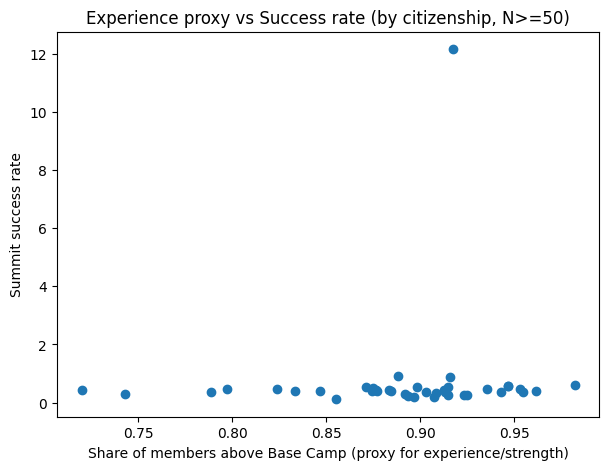

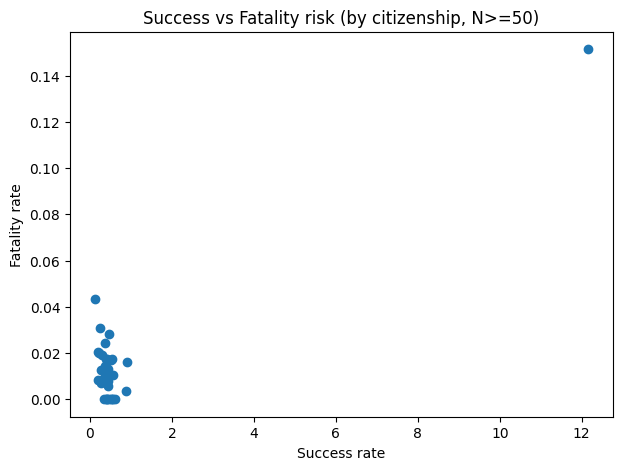

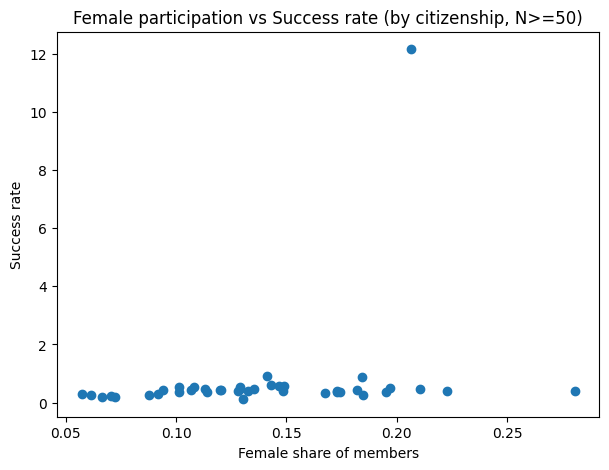

In [ ]:
# ---- 9) Plots (matplotlib only) ----

# Helper: filter to reduce noise from tiny sample sizes
plot_df = df[df["Total_Members"] >= 50].copy()

# 9.1 Experience proxy (Above BC) vs Success rate
plt.figure(figsize=(7,5))
plt.scatter(plot_df["Above_BC_Rate"], plot_df["Success_Rate"])
plt.xlabel("Share of members above Base Camp (proxy for experience/strength)")
plt.ylabel("Summit success rate")
plt.title("Experience proxy vs Success rate (by citizenship, N>=50)")
plt.show()

# 9.2 Success rate vs Fatality rate (risk-return style plot)
plt.figure(figsize=(7,5))
plt.scatter(plot_df["Success_Rate"], plot_df["Fatality_Rate"])
plt.xlabel("Success rate")
plt.ylabel("Fatality rate")
plt.title("Success vs Fatality risk (by citizenship, N>=50)")
plt.show()

# 9.3 Female share vs Success rate
plt.figure(figsize=(7,5))
plt.scatter(plot_df["Female_Share"], plot_df["Success_Rate"])
plt.xlabel("Female share of members")
plt.ylabel("Success rate")
plt.title("Female participation vs Success rate (by citizenship, N>=50)")
plt.show()



In [ ]:
# ---- 10) Regression at citizenship level (NOT individual logistic regression) ----
# This is a simple OLS on rates to quantify associations.
# You can report coefficients + p-values as descriptive inference.

import statsmodels.api as sm

reg_df = df[df["Total_Members"] >= 50].copy()

# Predict success rate using experience proxy + female share + log scale of participation
reg_df["log_members"] = np.log(reg_df["Total_Members"])

X = reg_df[["Above_BC_Rate", "Female_Share", "log_members"]]
X = sm.add_constant(X)
y = reg_df["Success_Rate"]

model_success = sm.OLS(y, X, missing="drop").fit()
print(model_success.summary())


                            OLS Regression Results                            
Dep. Variable:           Success_Rate   R-squared:                       0.092
Model:                            OLS   Adj. R-squared:                  0.017
Method:                 Least Squares   F-statistic:                     1.218
Date:                Sun, 04 Jan 2026   Prob (F-statistic):              0.317
Time:                        22:57:00   Log-Likelihood:                -79.166
No. Observations:                  40   AIC:                             166.3
Df Residuals:                      36   BIC:                             173.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -3.8604      4.906     -0.787

In [ ]:
# ---- 11) Second regression: Fatality rate ----

X2 = reg_df[["Above_BC_Rate", "Female_Share", "log_members"]]
X2 = sm.add_constant(X2)
y2 = reg_df["Fatality_Rate"]

model_fatality = sm.OLS(y2, X2, missing="drop").fit()
print(model_fatality.summary())


                            OLS Regression Results                            
Dep. Variable:          Fatality_Rate   R-squared:                       0.051
Model:                            OLS   Adj. R-squared:                 -0.028
Method:                 Least Squares   F-statistic:                    0.6440
Date:                Sun, 04 Jan 2026   Prob (F-statistic):              0.592
Time:                        22:58:10   Log-Likelihood:                 93.713
No. Observations:                  40   AIC:                            -179.4
Df Residuals:                      36   BIC:                            -172.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -0.0390      0.065     -0.599

In [ ]:
 # ---- 12) Create a clean output table + save it back to Drive ----
# Useful for sharing with teammates / putting into your report.

out_cols = [
    "Citizenship",
    "Total_Members",
    "Female_Share",
    "Above_BC_Rate",
    "Success_Rate",
    "Fatality_Rate",
    "Total_Success",
    "Total_Deaths",
    "Hired_Success_Share",
    "Hired_Death_Share"
]

out = df[out_cols].sort_values("Total_Members", ascending=False).copy()

# Save
out_path = "/content/drive/My Drive/QM_Grunge_Data/peak_member_summary_cleaned.csv"
out.to_csv(out_path, index=False)

print("Saved cleaned summary to:", out_path)
out.head(10)


Saved cleaned summary to: /content/drive/My Drive/QM_Grunge_Data/peak_member_summary_cleaned.csv


,Citizenship,Total_Members,Female_Share,Above_BC_Rate,Success_Rate,Fatality_Rate,Total_Success,Total_Deaths,Hired_Success_Share,Hired_Death_Share
195,Totals,14703.0,0.141196,0.887982,0.916004,0.015915,13468.0,234.0,0.521533,0.350427
169,USA,2457.0,0.120472,0.876272,0.446886,0.005698,1098.0,14.0,0.000000,0.000000
66,India,1311.0,0.196796,0.874905,0.504958,0.016781,662.0,22.0,0.012085,0.045455
151,UK,1268.0,0.093849,0.883281,0.445584,0.007886,565.0,10.0,0.000000,0.000000
33,China,1179.0,0.184054,0.916031,0.879559,0.003393,1037.0,4.0,0.281581,0.000000
75,Japan,648.0,0.132716,0.833333,0.387346,0.013889,251.0,9.0,0.000000,0.000000
97,Nepal,581.0,0.206540,0.917384,12.149742,0.151463,7059.0,88.0,0.952401,0.920455
123,S Korea,554.0,0.070397,0.893502,0.229242,0.019856,127.0,11.0,0.000000,0.000000
118,Russia,517.0,0.108317,0.914894,0.545455,0.017408,282.0,9.0,0.000000,0.000000
134,Spain,483.0,0.066253,0.896480,0.202899,0.008282,98.0,4.0,0.000000,0.000000
